# CH$_4$ - calculate global- annual-mean, latitudinal gradient and seasonality

Calculate global-mean, latitudinal gradient and seasonality.

## Imports

In [1]:
from pathlib import Path

import cf_xarray.units
import matplotlib.axes
import matplotlib.pyplot as plt
import pint_xarray
import xarray as xr
from pydoit_nb.config_handling import get_config_for_step_id

import local.binned_data_interpolation
import local.binning
import local.latitudinal_gradient
import local.raw_data_processing
import local.seasonality
import local.xarray_space
import local.xarray_time
from local.config import load_config_from_file

In [2]:
cf_xarray.units.units.define("ppm = 1 / 1000000")
cf_xarray.units.units.define("ppb = ppm / 1000")

pint_xarray.accessors.default_registry = pint_xarray.setup_registry(cf_xarray.units.units)

## Define branch this notebook belongs to

In [3]:
step: str = "calculate_ch4_monthly_fifteen_degree_pieces"

## Parameters

In [4]:
config_file: str = "../../dev-config-absolute.yaml"  # config file
step_config_id: str = "only"  # config ID to select for this branch

In [5]:
# Parameters
config_file = "/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/output-bundles/v1.0.0/v1.0.0-config.yaml"
step_config_id = "only"


## Load config

In [6]:
config = load_config_from_file(Path(config_file))
config_step = get_config_for_step_id(config=config, step=step, step_config_id=step_config_id)

## Action

### Load data

In [7]:
interpolated_spatial: xr.DataArray = xr.load_dataarray(  # type: ignore
    config_step.observational_network_interpolated_file
).pint.quantify()
interpolated_spatial

Magnitude,[[[1561.215 1565.0030769230768 1566.639 ... 1698.6899999999998 1717.12 1712.66] [1561.215 1565.52 1580.2340000000002 ... 1683.2320000000002 1697.9460000000001 1712.66] [1561.215 1575.4807142857144 1589.7464285714284 ... 1689.6064285714285 1703.872142857143 1712.6599999999999] [1561.215 1563.4523076923076 1572.8441176470587 ... 1692.2867647058822 1709.35 1712.66] [1561.215 1563.9692307692308 1565.6896153846153 ... 1691.292857142857 1711.9399999999998 1712.66] [1561.215 1564.4861538461537 1566.2065384615385 ... 1693.8828571428571 1714.5299999999997 1712.66]] [[1570.27 1571.5369230769234 1572.9430000000002 ... 1699.375 1706.65 1690.83] [1570.27 1571.39 1583.3633333333335 ... 1667.03 1678.9299999999998 1690.83] [1570.27 1575.838 1581.406 ... 1698.3 1698.3400000000001 1690.83] [1570.27 1571.9776923076922 1574.1442857142856 ... 1681.028 1705.89 1690.83] [1570.27 1571.8307692307692 1573.6853846153847 ... 1690.2791666666667 1706.1433333333334 1690.83] [1570.27 1571.6838461538462 1573.5384615384617 ... 1690.5325000000003 1706.3966666666668 1690.83]] [[1579.94 1578.550769230769 1580.389 ... 1689.5500000000002 1701.05 1682.35] [1579.94 1577.81 1589.0249999999999 ... 1667.71 1675.03 1682.35] [1579.94 1584.7500000000002 1589.56 ... 1688.9219999999998 1692.4740000000002 1682.35] [1579.94 1580.773076923077 1583.1385714285716 ... 1683.442 1706.15 1682.35] [1579.94 1580.0323076923075 1581.606153846154 ... 1689.29 1704.45 1682.35] [1579.94 1579.2915384615385 1580.8653846153848 ... 1687.59 1702.75 1682.35]] ... [[1888.26 1887.6475 1888.2465 ... 2019.24 2033.92 2013.3850000000002] [1888.26 1887.53 1888.0 ... 2007.7366666666667 2009.5983333333336 2011.46] [1888.26 1895.375 1902.49 ... 2005.0935 2005.95 2015.31] [1888.26 1888.0 1886.75 ... 2028.52 2024.1 2019.16] [1888.26 1887.8825 1888.4814999999999 ... 2002.1525 2017.5149999999999 2017.2350000000001] [1888.26 1887.7649999999999 1888.364 ... 2015.87 2025.7175000000002 2015.31]] [[1882.84 1883.4325 1884.2925 ... 2021.57 2025.865 2014.905] [1882.84 1883.72 1883.61 ... 2023.0 2018.54 2014.08] [1882.84 1893.2883333333332 1903.7366666666667 ... 2007.4115 2008.38 2015.73] [1882.8399999999997 1882.57 1882.21 ... 2039.59 2027.92 2017.38] [1882.84 1882.8575 1883.7175 ... 2008.9283333333335 2020.7507142857141 2016.555] [1882.84 1883.145 1884.005 ... 2024.1214285714286 2023.307857142857 2015.73]] [[1874.47 1875.0749999999998 1876.26 ... 2019.61 2032.89 2019.615] [1874.47 1875.37 1875.17 ... 2031.7450000000001 2025.4425 2019.14] [1874.47 1875.474 1876.478 ... 2008.4895 2012.955 2020.0900000000001] [1874.4699999999998 1874.19 1874.02 ... 2054.8166666666666 2037.9283333333333 2021.04] [1874.47 1874.485 1875.67 ... 2013.2833333333335 2028.3300000000002 2020.565] [1874.47 1874.78 1875.9650000000001 ... 2035.6200000000001 2030.61 2020.0900000000001]]]
Units,ppb


### Drop out any years that have nan

These break everything later on

In [8]:
interpolated_spatial_nan_free = local.xarray_time.convert_year_month_to_time(
    local.xarray_time.convert_time_to_year_month(interpolated_spatial).dropna("year")
)

### Longitudinal-mean

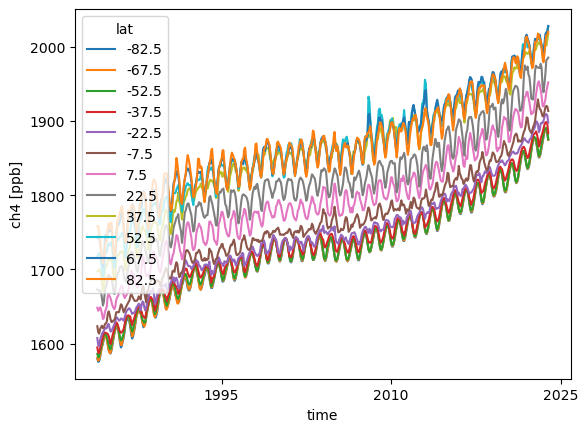

In [9]:
lon_mean = interpolated_spatial_nan_free.mean(dim="lon")
lon_mean.plot(hue="lat")  # type: ignore

### Global-, annual-mean

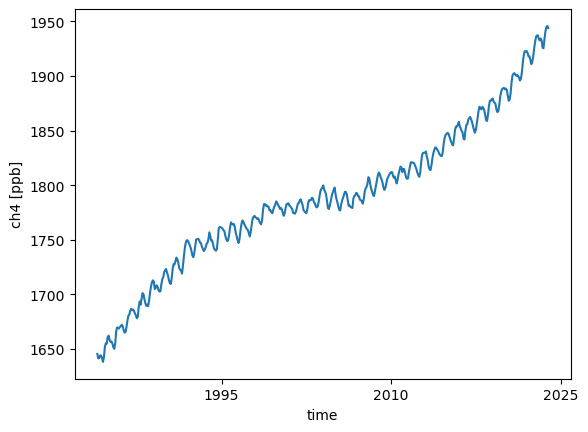

In [10]:
global_mean = local.xarray_space.calculate_global_mean_from_lon_mean(lon_mean)
global_mean.plot()  # type: ignore

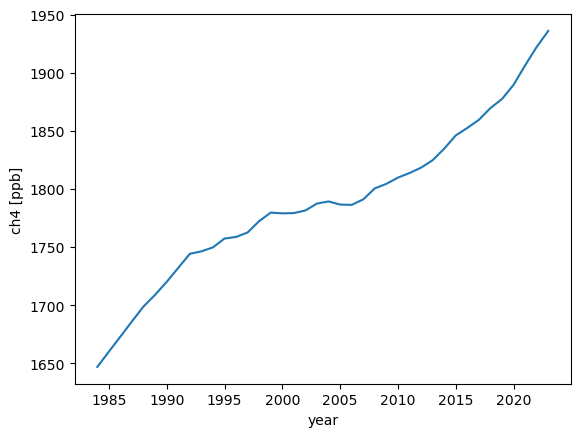

In [11]:
global_annual_mean = global_mean.groupby("time.year").mean()
global_annual_mean.plot()  # type: ignore

### Latitudinal gradient

In [12]:
(
    lat_residuals_annual_mean,
    full_eofs_pcs,
) = local.latitudinal_gradient.calculate_eofs_pcs(lon_mean, global_mean)
full_eofs_pcs

<xarray.Dataset> Size: 6kB
Dimensions:               (lat: 12, eof: 12, year: 40)
Coordinates:
  * lat                   (lat) float64 96B -82.5 -67.5 -52.5 ... 52.5 67.5 82.5
  * eof                   (eof) int64 96B 0 1 2 3 4 5 6 7 8 9 10 11
  * year                  (year) int64 320B 1984 1985 1986 ... 2021 2022 2023
Data variables:
    eofs                  (lat, eof) float64 1kB [ppb] 0.3003 ... -0.05329
    principal-components  (year, eof) float64 4kB [] -182.0 -26.9 ... 5.831e-14

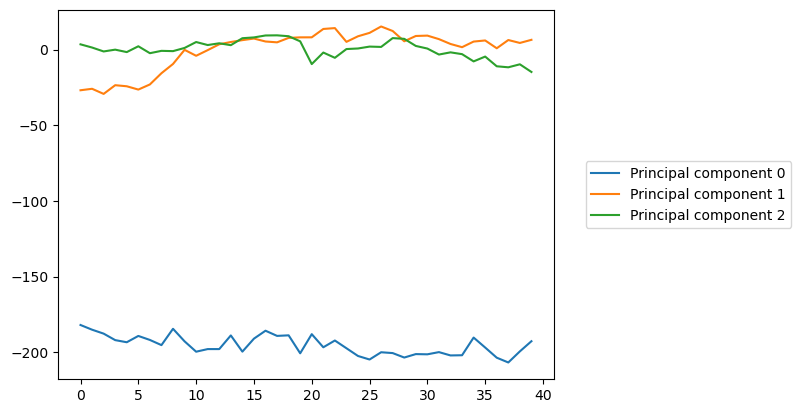

In [13]:
fig, ax = plt.subplots()
n_eofs_to_show = 3

for i in range(n_eofs_to_show):
    ax.plot(
        full_eofs_pcs["principal-components"].sel(eof=i).data.m,
        label=f"Principal component {i}",
    )

ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5))

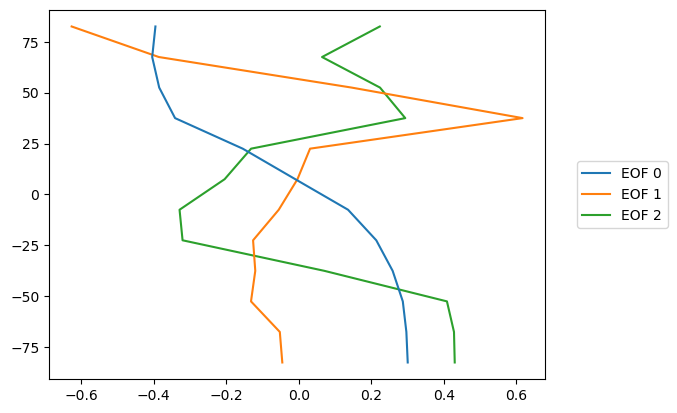

In [14]:
fig, ax = plt.subplots()

for i in range(3):
    ax.plot(
        full_eofs_pcs["eofs"].sel(eof=i).data.m,
        full_eofs_pcs["lat"].data,
        label=f"EOF {i}",
        zorder=2 - i / 10,
    )

ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5))

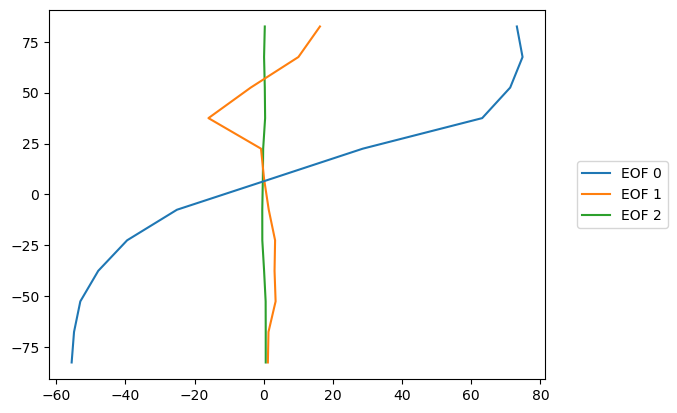

In [15]:
fig, ax = plt.subplots()

for i in range(3):
    ax.plot(
        full_eofs_pcs["principal-components"].sel(eof=i).isel(year=1) @ full_eofs_pcs["eofs"].sel(eof=i),
        full_eofs_pcs["lat"],
        label=f"EOF {i}",
        zorder=2 - i / 10,
    )

ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5))

In [16]:
eofs_pcs = full_eofs_pcs.sel(eof=range(config_step.lat_gradient_n_eofs_to_use))
eofs_pcs

Magnitude,[[0.30025018318312763 -0.04561164586679519] [0.2965177211597987 -0.05247176094473515] [0.28669368891135655 -0.13192160300553288] [0.25868274423756865 -0.12013809648787833] [0.21354096993148647 -0.12621426172104994] [0.13572417606734882 -0.05541590622430623] [-0.009763875456997667 -0.003807495208314669] [-0.15477242906216288 0.030927020383364392] [-0.3413313593968472 0.6169182583271611] [-0.38507759994402174 0.1453908598400114] [-0.40439734737743105 -0.3861098085045183] [-0.3954963081830014 -0.6265384717298393]]
Units,ppb
Magnitude,[[-181.96455491656798 -26.899549396283643] [-185.07036998882754 -25.931456273368024] [-187.66848597432005 -29.30254418787181] [-191.95597149687063 -23.555639414150583] [-193.35726365360046 -24.267102482764823] [-189.19301836605945 -26.448557792381166] [-191.84021577313638 -23.063362973218567] [-195.25358261404398 -15.644980568087103] [-184.47372167316075 -9.53623620249803] [-192.7608486126182 -0.2030356999623798] [-199.60426264919815 -4.1309350471026285] [-197.87464470111703 -0.39157903003960653] [-197.8765838415786 3.4812293448022174] [-188.8536126016339 4.975849705822549] [-199.56303374459523 6.204427988571532] [-190.98456783145042 7.254331894702466] [-185.74285457303208 5.3125948291215215] [-189.16391806975932 4.75265960487314] [-188.79057840509148 7.687198637456791] [-200.65959529471274 8.043188347565552] [-188.0157638974525 8.06633885464245] [-196.68731661761015 13.590402250195218] [-192.21199032763428 14.159838698725316] [-197.3187701577451 5.076262360138612] [-202.435064974493 8.757431460027245] [-204.76418639673113 11.006483665925181] [-199.96657588637976 15.231320740657305] [-200.51742635973 12.240867215600435] [-203.4647316418192 5.457914692843327] [-201.18754521482148 8.95337159982959] [-201.33462062202418 9.198991738173637] [-199.87841414146047 6.876955037340297] [-202.07109374842446 3.6778660671565455] [-201.94652441325513 1.5497056906709181] [-190.26960725603203 5.26126806488389] [-196.8554579246131 5.989485812946594] [-203.56222181222165 0.8387463066479733] [-206.72328051568536 6.282478740024786] [-199.40153791374337 4.349681363078166] [-192.67875910417692 6.414157450737971]]
Units,dimensionless


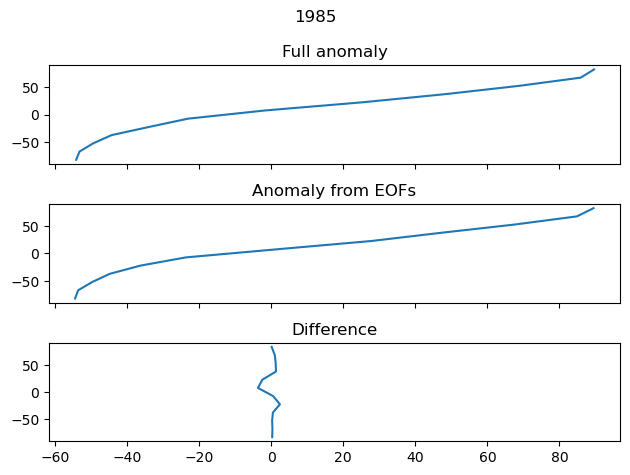

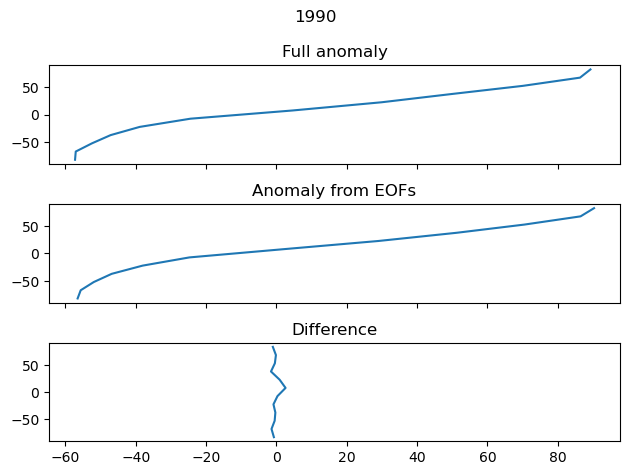

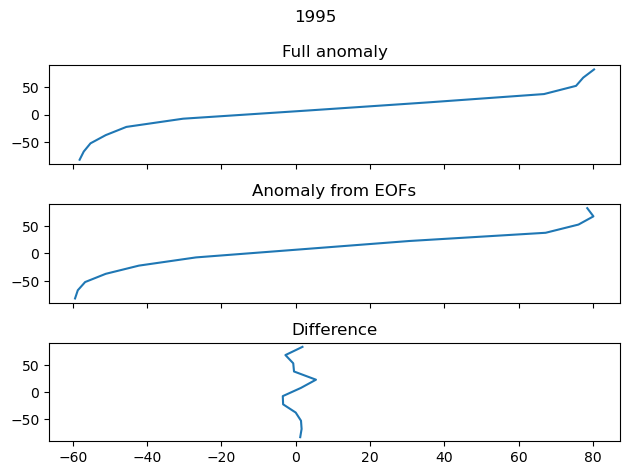

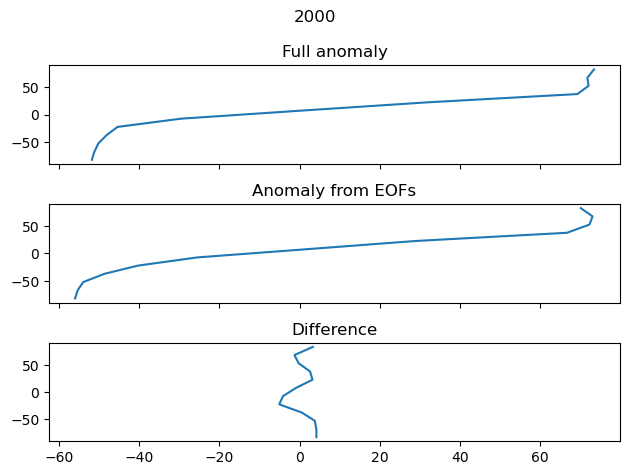

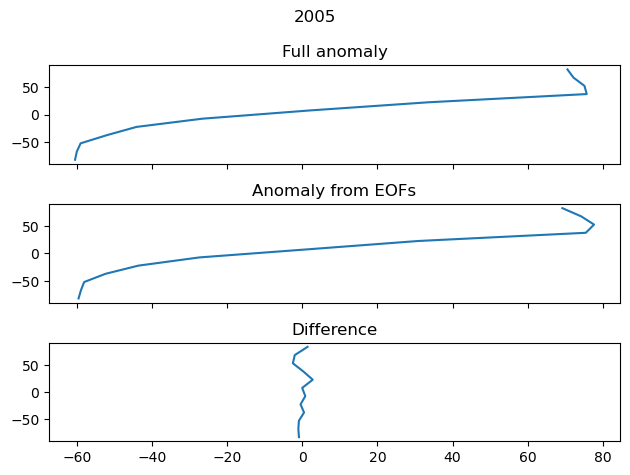

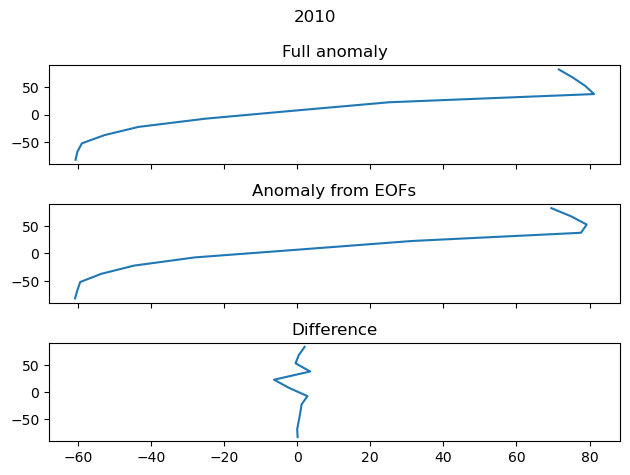

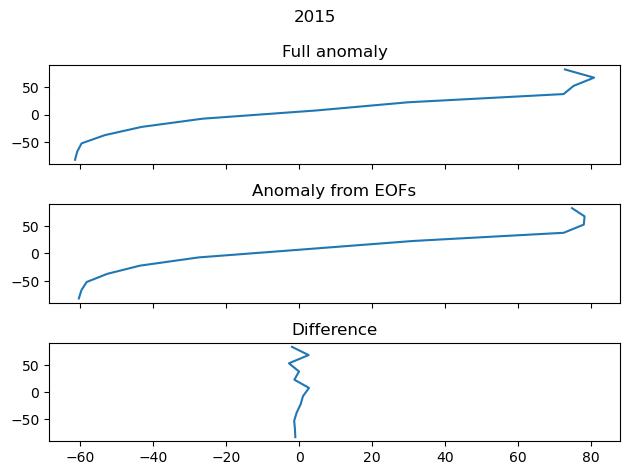

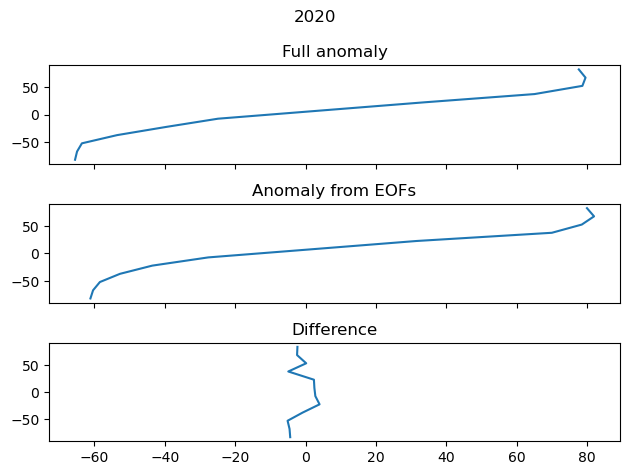

In [17]:
latitudinal_anomaly_from_eofs = eofs_pcs["principal-components"] @ eofs_pcs["eofs"]

for year in latitudinal_anomaly_from_eofs["year"]:
    if year % 5:
        continue

    fig, axes = plt.subplots(nrows=3, sharex=True, sharey=True)
    if isinstance(axes, matplotlib.axes.Axes):
        raise TypeError(type(axes))

    selected = lat_residuals_annual_mean.sel(year=year)
    axes[0].plot(selected.data.m, lat_residuals_annual_mean.lat)
    axes[0].set_title("Full anomaly")

    selected_eofs = latitudinal_anomaly_from_eofs.sel(year=year)
    axes[1].plot(selected_eofs.data.m, latitudinal_anomaly_from_eofs.lat)
    axes[1].set_title("Anomaly from EOFs")

    axes[2].plot(selected.data.m - selected_eofs.data.m, lat_residuals_annual_mean.lat)
    axes[2].set_title("Difference")

    axes[0].set_ylim([-90, 90])

    plt.suptitle(str(int(year)))
    plt.tight_layout()
    plt.show()

### Seasonality

In [18]:
(
    seasonality,
    relative_seasonality,
    lon_mean_ym_monthly_anomalies,
) = local.seasonality.calculate_seasonality(
    lon_mean=lon_mean,
    global_mean=global_mean,
)

/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/src/local/seasonality.py:29: UserWarning: The `squeeze` kwarg to GroupBy is being removed.Pass .groupby(..., squeeze=False) to disable squeezing, which is the new default, and to silence this warning.
  lon_mean_ym_annual_mean_monthly = lon_mean_ym_annual_mean.groupby("lat", squeeze=True).apply(  # type: ignore
/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/.pixi/envs/all-dev/lib/python3.11/importlib/__init__.py:126: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  return _bootstrap._gcd_import(name[level:], package, level)


Calculating output values:   0%|                                                                                                                                                                                      | 0/480 [00:00<?, ?it/s]

Calculating output values: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 480/480 [00:00<00:00, 13947.11it/s]


/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/src/local/seasonality.py:29: UserWarning: The `squeeze` kwarg to GroupBy is being removed.Pass .groupby(..., squeeze=False) to disable squeezing, which is the new default, and to silence this warning.
  lon_mean_ym_annual_mean_monthly = lon_mean_ym_annual_mean.groupby("lat", squeeze=True).apply(  # type: ignore


Calculating output values:   0%|                                                                                                                                                                                      | 0/480 [00:00<?, ?it/s]

...

Calculating output values:   0%|                                                                                                                                                                                      | 0/480 [00:00<?, ?it/s]

Calculating output values: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 480/480 [00:00<00:00, 19731.32it/s]


/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/src/local/seasonality.py:29: UserWarning: The `squeeze` kwarg to GroupBy is being removed.Pass .groupby(..., squeeze=False) to disable squeezing, which is the new default, and to silence this warning.
  lon_mean_ym_annual_mean_monthly = lon_mean_ym_annual_mean.groupby("lat", squeeze=True).apply(  # type: ignore


Calculating output values:   0%|                                                                                                                                                                                      | 0/480 [00:00<?, ?it/s]

Calculating output values: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 480/480 [00:00<00:00, 16283.29it/s]

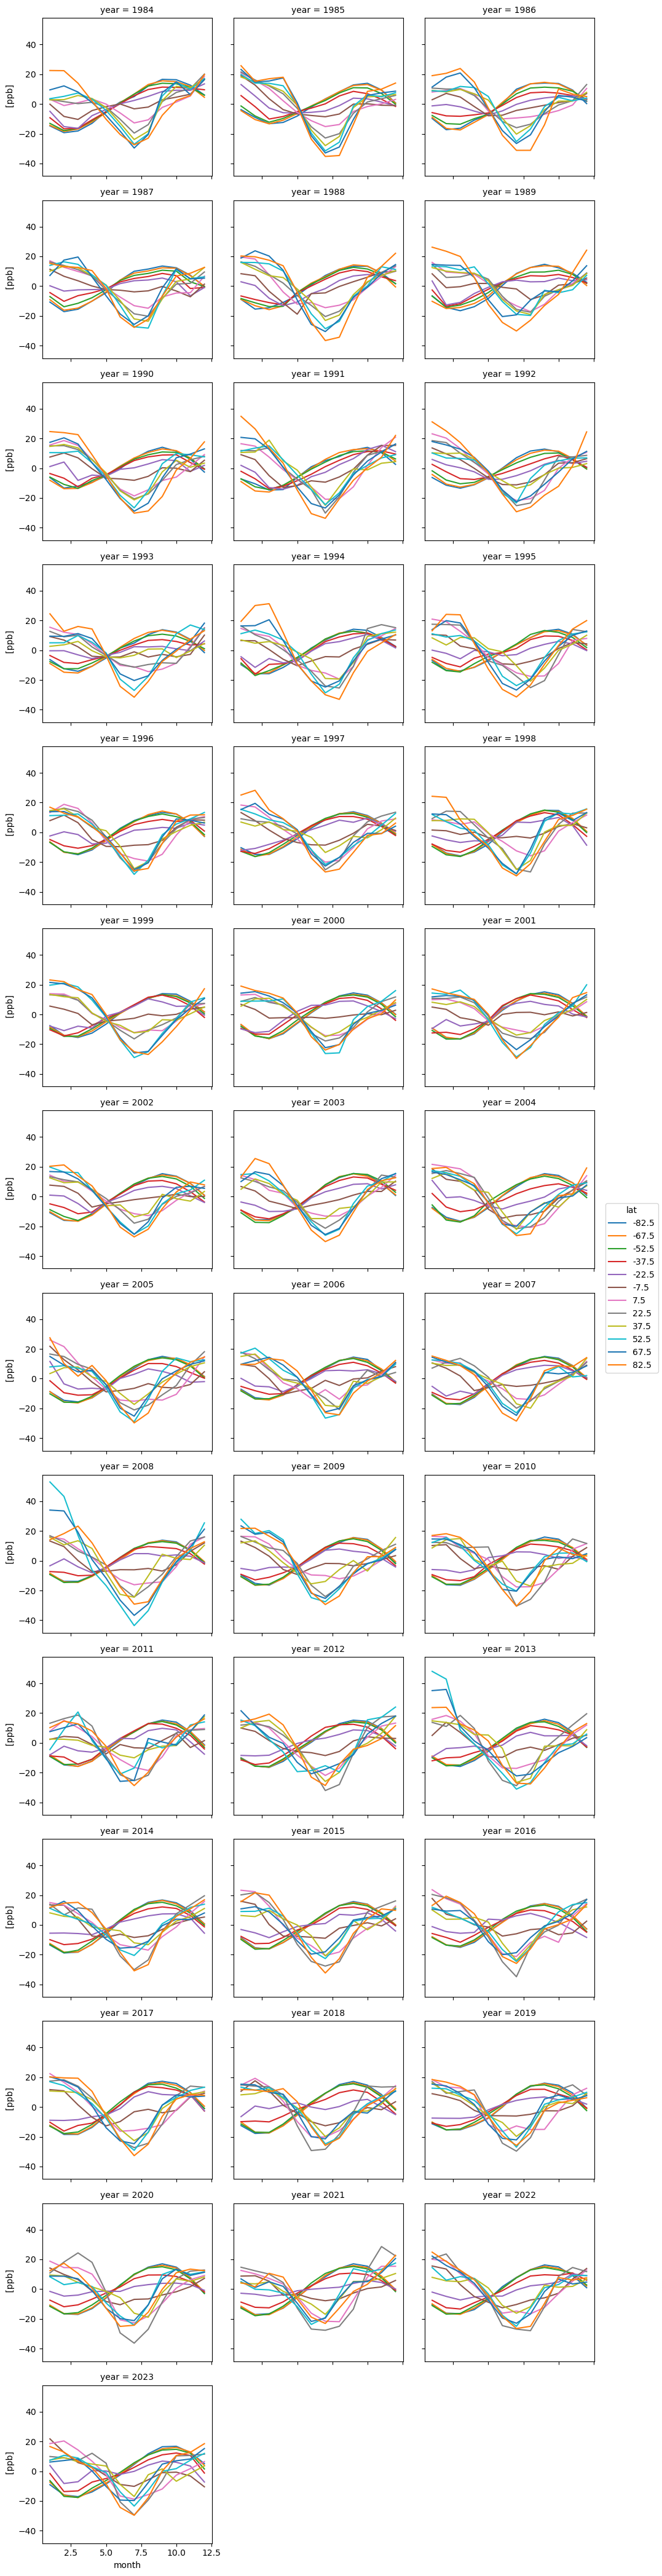

In [19]:
lon_mean_ym_monthly_anomalies.plot.line(hue="lat", col="year", col_wrap=3)

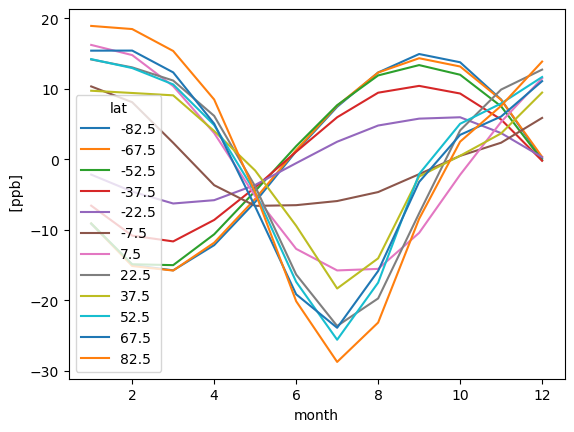

In [20]:
seasonality.plot.line(hue="lat")

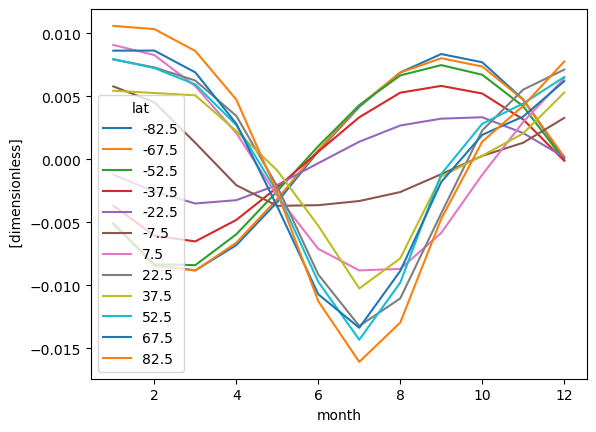

In [21]:
relative_seasonality.plot.line(hue="lat")

### Save

In [22]:
config_step.observational_network_global_annual_mean_file.parent.mkdir(exist_ok=True, parents=True)
global_annual_mean.pint.dequantify().to_netcdf(config_step.observational_network_global_annual_mean_file)
global_annual_mean

Magnitude,[1646.820852094638 1659.9908151704774 1672.9498232983997 1686.0799341822894 1698.8642073905241 1708.8882532396535 1719.9836228093257 1732.0285995436536 1744.0833256875658 1746.2544638638456 1749.6687004078276 1757.2590091447728 1758.6470145224164 1762.4813996223993 1772.2844894650389 1779.590724804816 1778.9182295419314 1779.1799675022232 1781.4246086661612 1787.357020805297 1789.1828639234343 1786.4839927938483 1786.248211711816 1790.9319684047914 1800.4309602949477 1804.3069178603637 1809.6775079395593 1813.6029117916596 1818.2588797936153 1824.620466425247 1834.5484724333207 1845.959374022509 1852.3977591829814 1859.3854928114206 1869.5218978539879 1877.2647164703437 1889.4786016246528 1906.18114481266 1922.0865734906138 1935.8751296738]
Units,ppb


In [23]:
config_step.observational_network_latitudinal_gradient_eofs_file.parent.mkdir(exist_ok=True, parents=True)
eofs_pcs.pint.dequantify().to_netcdf(config_step.observational_network_latitudinal_gradient_eofs_file)
eofs_pcs

Magnitude,[[0.30025018318312763 -0.04561164586679519] [0.2965177211597987 -0.05247176094473515] [0.28669368891135655 -0.13192160300553288] [0.25868274423756865 -0.12013809648787833] [0.21354096993148647 -0.12621426172104994] [0.13572417606734882 -0.05541590622430623] [-0.009763875456997667 -0.003807495208314669] [-0.15477242906216288 0.030927020383364392] [-0.3413313593968472 0.6169182583271611] [-0.38507759994402174 0.1453908598400114] [-0.40439734737743105 -0.3861098085045183] [-0.3954963081830014 -0.6265384717298393]]
Units,ppb
Magnitude,[[-181.96455491656798 -26.899549396283643] [-185.07036998882754 -25.931456273368024] [-187.66848597432005 -29.30254418787181] [-191.95597149687063 -23.555639414150583] [-193.35726365360046 -24.267102482764823] [-189.19301836605945 -26.448557792381166] [-191.84021577313638 -23.063362973218567] [-195.25358261404398 -15.644980568087103] [-184.47372167316075 -9.53623620249803] [-192.7608486126182 -0.2030356999623798] [-199.60426264919815 -4.1309350471026285] [-197.87464470111703 -0.39157903003960653] [-197.8765838415786 3.4812293448022174] [-188.8536126016339 4.975849705822549] [-199.56303374459523 6.204427988571532] [-190.98456783145042 7.254331894702466] [-185.74285457303208 5.3125948291215215] [-189.16391806975932 4.75265960487314] [-188.79057840509148 7.687198637456791] [-200.65959529471274 8.043188347565552] [-188.0157638974525 8.06633885464245] [-196.68731661761015 13.590402250195218] [-192.21199032763428 14.159838698725316] [-197.3187701577451 5.076262360138612] [-202.435064974493 8.757431460027245] [-204.76418639673113 11.006483665925181] [-199.96657588637976 15.231320740657305] [-200.51742635973 12.240867215600435] [-203.4647316418192 5.457914692843327] [-201.18754521482148 8.95337159982959] [-201.33462062202418 9.198991738173637] [-199.87841414146047 6.876955037340297] [-202.07109374842446 3.6778660671565455] [-201.94652441325513 1.5497056906709181] [-190.26960725603203 5.26126806488389] [-196.8554579246131 5.989485812946594] [-203.56222181222165 0.8387463066479733] [-206.72328051568536 6.282478740024786] [-199.40153791374337 4.349681363078166] [-192.67875910417692 6.414157450737971]]
Units,dimensionless


In [24]:
# Use relative seasonality for CH4
config_step.observational_network_seasonality_file.parent.mkdir(exist_ok=True, parents=True)
relative_seasonality.pint.dequantify().to_netcdf(config_step.observational_network_seasonality_file)
relative_seasonality

Magnitude,[[-0.0051226852965690845 -0.008387769597384218 -0.008811493636334888 -0.006812219981307825 -0.0033878728127088916 0.0006388615120626364 0.004161478311754434 0.006886680764813426 0.008351139634428418 0.007696591107269999 0.004740752419016826 4.653865624431706e-05] [-0.00509152838523204 -0.008467450070263949 -0.008827553276804515 -0.006617708383023418 -0.003143760722486265 0.0007289177614685831 0.0042479343130500434 0.006882502999173517 0.008016753148442373 0.007361954431087585 0.0047187649848191605 0.00019117416756158235] [-0.0050875848218163 -0.008327025369013417 -0.008398690362669655 -0.005952326147596656 -0.0025260167907970752 0.0010394630227596707 0.004291999647509803 0.006653539869970668 0.007472693804945091 0.006706926071033974 0.004201632683037267 -7.461098102467155e-05] [-0.0036798495896156213 -0.0060565469812546594 -0.006515892760383059 -0.004813044822732985 -0.002230124537773169 0.0005981372812424664 0.0033331563949924787 0.005283163994878391 0.0058237772377420964 0.005218277175112763 0.0031562154438723538 -0.00011726846841590901] [-0.0012164915657797138 -0.0025633713141782442 -0.003507904594395352 -0.003244622311933295 -0.002036202871267038 -0.00030749148529465344 0.0013930385670678934 0.002679208542864843 0.003224743501963814 0.0033341066251214367 0.0020768456467650576 0.00016813942045530993] [0.005781769032355198 0.004528704185532622 0.0013076308139161191 -0.0020552744609502894 -0.0036965847481888535 -0.0036405240340437956 -0.003312587695409286 -0.0026004193280833123 -0.001181183328723443 0.0002707000803422992 0.00131484148179875 0.003282925331496022] [0.009073068423141248 0.00826725740089856 0.005802315583863598 0.0020781466949309044 -0.0029228012673267662 -0.007107329107230384 -0.008817885062699104 -0.008696353020649401 -0.005837331966472479 -0.0012270775202732698 0.0029625393622471075 0.006425447983539518] [0.007918352648278634 0.007291723625277042 0.006246950682592953 0.003442519078959749 -0.002146481341560613 -0.00914178089950147 -0.013224370355145064 -0.011038429609950893 -0.004286996658076247 0.0022937346934628106 0.005530855023814402 0.007113921115920793] [0.005438235080832716 0.005259633412320483 0.005073846343946591 0.002241565020006756 -0.0008914645956677321 -0.005274012666873116 -0.010251242383052498 -0.00785849500818662 -0.0013656471641913923 0.0002802132913734132 0.0020538992248326587 0.005293465336048312] [0.007946339322818208 0.007237378836277881 0.005939417975088039 0.0027121448669767587 -0.002616589378999846 -0.009719591529517022 -0.014316871540032179 -0.00978623235227961 -0.0011674869843336778 0.0028174560953039872 0.004427758390636104 0.006526273276219969] [0.00861769495366677 0.008624369403280529 0.00689459575287358 0.0028264942314963474 -0.003751948560199484 -0.01071250628594943 -0.013367598544819781 -0.008861353534930498 -0.0017993705755580142 0.0019383124251159056 0.0033919916467516 0.00619931855198792] [0.010580687673979067 0.01033191712318273 0.008593674966138014 0.004740926685138956 -0.002627853288798649 -0.011258683449265608 -0.016076871569108666 -0.012953646769150874 -0.0047224360274700245 0.001398395011896349 0.004240975503698059 0.00775291611095541]]
Units,dimensionless
